In [203]:
print(hello)

NameError: name 'hello' is not defined

In [204]:
import selfies as sf
from rdkit import Chem

def smiles_to_selfies(smiles):
    """Converts a SMILES string to SELFIES with error handling."""
    try:
        # Check if the SMILES string is valid using RDKit
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            print(f"❌ Invalid SMILES: {smiles}")
            return None

        # Convert to SELFIES
        selfies_str = sf.encoder(smiles)
        print(f"✅ SELFIES: {selfies_str}")
        return selfies_str

    except Exception as e:
        print(f"❌ Error converting SMILES to SELFIES: {e}")
        return None

if __name__ == "__main__":
    smiles_string = "O=[N+]([O-])C1NCNN1"
    selfies_string = smiles_to_selfies(smiles_string)


✅ SELFIES: [O][=N+1][Branch1][C][O-1][C][N][C][N][N][Ring1][Branch1]


## First, we want to clean our rings and sidechains datasets. Ensuring unique id’s of the same type, and consistent writing of nodes and edges.
### Rings: id, smiles, nodes, edges, sub_points 
### Sidechains: id, smiles, nodes, edges

In [148]:
import pandas as pd

# Define file paths
sidechains_file = r"C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination\data\sidechain_db.parquet"
rings_file = r"C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination\data\ring_db.parquet"

# Load Parquet files into Pandas DataFrames
df_sidechains = pd.read_parquet(sidechains_file)
df_rings = pd.read_parquet(rings_file)

# Display the first few rows of each DataFrame
print("Combinations DataFrame:")
print(df_sidechains)

print("\nRings DataFrame:")
print(df_rings)

Combinations DataFrame:
        smiles                                              nodes  \
0            C                                        [(0, 'C*')]   
1          C=C                              [(0, 'C'), (1, 'C*')]   
2          C#C                              [(0, 'C'), (1, 'C*')]   
3            N                                        [(0, 'N*')]   
4        CN(C)                    [(0, 'C'), (2, 'C'), (1, 'N*')]   
5       C/N=C/                    [(0, 'C'), (1, 'N'), (2, 'C*')]   
6          N=C                              [(0, 'N'), (1, 'C*')]   
7          N#C                              [(0, 'N'), (1, 'C*')]   
8     c1ccccc1  [(6, 'C'), (4, 'C'), (1, 'C*'), (2, 'C'), (3, ...   
9          O=C                              [(0, 'O'), (1, 'C*')]   
10      CC(=O)                    [(0, 'C'), (1, 'C*'), (2, 'O')]   
11     COC(=O)          [(3, 'O'), (2, 'C*'), (0, 'C'), (1, 'O')]   
12      NC(=O)                    [(0, 'N'), (2, 'O'), (1, 'C*')]   
13      O=

In [107]:
import pandas as pd

# File paths
file1 = r"C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination\data\d3tales_cut_2_rings.parquet"
file2 = r"C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination\data\ocelot_cut_2_rings.parquet"

# Load the Parquet files
df1 = pd.read_parquet(file1)
df2 = pd.read_parquet(file2)

# Merge both DataFrames using an outer join on all columns
df_rings = pd.concat([df1, df2], axis=0, join="outer", ignore_index=True)

# Fill missing values with 0.0
df_rings = df_rings.fillna(0.0)

# Convert inconsistent data types to string
df_rings = df_rings.astype(str)

# Display the DataFrame
print(df_rings)


                                                   nodes  \
0      [(2, 'C*'), (3, 'C'), (4, 'C'), (5, 'C*'), (43...   
1      [(7, 'C*'), (8, 'C'), (9, 'C'), (10, 'C'), (11...   
2      [(5, 'C*'), (6, 'C'), (7, 'C'), (8, 'C'), (9, ...   
3      [(2, 'C*'), (3, 'C'), (4, 'C'), (5, 'C'), (6, ...   
4      [(42, 'C'), (43, 'C'), (44, 'S'), (14, 'C*'), ...   
...                                                  ...   
18891  [(1, 'C*'), (2, 'N'), (3, 'C*'), (5, 'C'), (6,...   
18892  [(1, 'C*'), (2, 'N'), (3, 'C'), (4, 'C'), (5, ...   
18893  [(1, 'C*'), (2, 'N'), (3, 'C'), (4, 'C'), (5, ...   
18894  [(1, 'C*'), (2, 'N'), (3, 'C*'), (5, 'C'), (6,...   
18895  [(1, 'C*'), (2, 'N'), (3, 'C*'), (5, 'C'), (6,...   

                                                   edges parent_db  \
0      ['2,3: Aromatic', '2,44: Aromatic', '3,4: Arom...   d3tales   
1      ['7,8: Aromatic', '7,12: Aromatic', '8,9: Arom...   d3tales   
2      ['5,6: Aromatic', '5,10: Aromatic', '6,7: Arom...   d3tales   

In [108]:
print("Sidechains DataFrame Columns and Data Types:")
print(df_sidechains.dtypes)

print("\nRings DataFrame Columns and Data Types:")
print(df_rings.dtypes)


Sidechains DataFrame Columns and Data Types:
smiles    object
nodes     object
edges     object
id        object
dtype: object

Rings DataFrame Columns and Data Types:
nodes                object
edges                object
parent_db            object
id                   object
sub_points           object
subgraph_smiles      object
atom_C               object
atom_S               object
atom_N               object
atom_O               object
atom_B               object
rings                object
atom_H               object
atoms_total          object
methylated_smiles    object
rings_minimal        object
atom_P               object
atom_Se              object
atom_Te              object
atom_Si              object
atom_As              object
dtype: object


In [109]:
import hashlib

# Function to hash the 'smiles' value
def hash_smiles(smiles):
    return hashlib.sha256(smiles.encode()).hexdigest()

# Apply the hash function to the 'smiles' column and replace 'id'
df_sidechains['id'] = df_sidechains['smiles'].apply(hash_smiles)

# Ensure 'id' is treated as an object (string)
df_sidechains['id'] = df_sidechains['id'].astype(str)

# Verify changes
print(df_sidechains.dtypes)


smiles    object
nodes     object
edges     object
id        object
dtype: object


In [205]:
import pandas as pd

# Example list of SMILES strings (comma-separated)
smiles_list = "C[Xe],C=C[Xe],C#C[Xe],N[Xe],CN(C)[Xe],C/N=C/[Xe],N=C[Xe],N#C[Xe],[Xe]c1ccccc1,O=C[Xe],CC(=O)[Xe],COC(=O)[Xe],NC(=O)[Xe],O=C(O)[Xe],CN(C)C(=O)[Xe],[Xe]c1ccccn1,F[Xe],Br[Xe],I[Xe],S[Xe],O[Xe],Cl[Xe],CO[Xe],[Xe]c1ccco1,[Xe]C1=CC=C[NH]1,O=S(=O)(O)[Xe],O=[N+]([O-])[Xe],O=P(O)(O)[Xe],NS(=O)(=O)[Xe],[Xe]c1cccs1,B[Xe],OB(O)[Xe],FB(F)[Xe],[SeH][Xe]"

# Split the string into a list
smiles_split = smiles_list.split(',')

# Create the DataFrame
sc_df = pd.DataFrame(smiles_split, columns=['smiles'])

# Display the DataFrame
print(sc_df)


              smiles
0              C[Xe]
1            C=C[Xe]
2            C#C[Xe]
3              N[Xe]
4          CN(C)[Xe]
5         C/N=C/[Xe]
6            N=C[Xe]
7            N#C[Xe]
8       [Xe]c1ccccc1
9            O=C[Xe]
10        CC(=O)[Xe]
11       COC(=O)[Xe]
12        NC(=O)[Xe]
13        O=C(O)[Xe]
14    CN(C)C(=O)[Xe]
15      [Xe]c1ccccn1
16             F[Xe]
17            Br[Xe]
18             I[Xe]
19             S[Xe]
20             O[Xe]
21            Cl[Xe]
22            CO[Xe]
23       [Xe]c1ccco1
24  [Xe]C1=CC=C[NH]1
25    O=S(=O)(O)[Xe]
26  O=[N+]([O-])[Xe]
27     O=P(O)(O)[Xe]
28    NS(=O)(=O)[Xe]
29       [Xe]c1cccs1
30             B[Xe]
31         OB(O)[Xe]
32         FB(F)[Xe]
33         [SeH][Xe]


In [206]:
import pandas as pd
import networkx as nx
from rdkit import Chem
from rdkit.Chem import rdchem
from rdkit.Chem.rdmolops import GetAdjacencyMatrix

# Function to convert SMILES to graph and extract nodes/edges
def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None  # Return None if SMILES is invalid
    
    # Create a NetworkX graph
    G = nx.Graph()

    # Add nodes (atoms)
    for atom in mol.GetAtoms():
        G.add_node(atom.GetIdx(), label=atom.GetSymbol())

    # Add edges (bonds)
    for bond in mol.GetBonds():
        G.add_edge(
            bond.GetBeginAtomIdx(),
            bond.GetEndAtomIdx(),
            bond_type=str(bond.GetBondType())
        )

    # Extract node labels
    nodes = [(n, G.nodes[n]['label']) for n in G.nodes()]
    
    # Extract edges with bond types
    edges = [(u, v, G.edges[u, v]['bond_type']) for u, v in G.edges()]

    return nodes, edges

# Apply function to each SMILES in the DataFrame
sc_df['nodes'], sc_df['edges'] = zip(*sc_df['smiles'].apply(smiles_to_graph))

# Display the updated DataFrame
print(sc_df)


              smiles                                              nodes  \
0              C[Xe]                                  [(0, C), (1, Xe)]   
1            C=C[Xe]                          [(0, C), (1, C), (2, Xe)]   
2            C#C[Xe]                          [(0, C), (1, C), (2, Xe)]   
3              N[Xe]                                  [(0, N), (1, Xe)]   
4          CN(C)[Xe]                  [(0, C), (1, N), (2, C), (3, Xe)]   
5         C/N=C/[Xe]                  [(0, C), (1, N), (2, C), (3, Xe)]   
6            N=C[Xe]                          [(0, N), (1, C), (2, Xe)]   
7            N#C[Xe]                          [(0, N), (1, C), (2, Xe)]   
8       [Xe]c1ccccc1  [(0, Xe), (1, C), (2, C), (3, C), (4, C), (5, ...   
9            O=C[Xe]                          [(0, O), (1, C), (2, Xe)]   
10        CC(=O)[Xe]                  [(0, C), (1, C), (2, O), (3, Xe)]   
11       COC(=O)[Xe]          [(0, C), (1, O), (2, C), (3, O), (4, Xe)]   
12        NC(=O)[Xe]     

In [207]:
def process_xe_atoms(nodes, edges):
    """
    - Identifies Xe atoms in the graph.
    - Modifies the label of the atoms bonded to Xe by adding '*'.
    - Removes Xe nodes and their corresponding edges.
    """
    if nodes is None or edges is None:
        return nodes, edges  # Skip if invalid

    # Convert nodes and edges to dict/lists for modification
    node_dict = {idx: label for idx, label in nodes}
    edges_list = edges[:]

    # Identify Xe atoms
    xe_atoms = [idx for idx, label in nodes if label == "Xe"]
    
    # Identify atoms connected to Xe and update labels
    updated_nodes = set(nodes)  # Using set to allow modification
    updated_edges = [edge for edge in edges_list if edge[0] not in xe_atoms and edge[1] not in xe_atoms]

    for xe in xe_atoms:
        for u, v, bond_type in edges_list:
            if u == xe:
                updated_nodes.discard((u, node_dict[u]))  # Remove Xe
                updated_nodes.discard((v, node_dict[v]))  # Remove the bound atom temporarily
                updated_nodes.add((v, node_dict[v] + "*"))  # Re-add the bound atom with '*'
            elif v == xe:
                updated_nodes.discard((v, node_dict[v]))  # Remove Xe
                updated_nodes.discard((u, node_dict[u]))  # Remove the bound atom temporarily
                updated_nodes.add((u, node_dict[u] + "*"))  # Re-add the bound atom with '*'

    return list(updated_nodes), updated_edges  # Convert back to list format

# Apply Xe processing to all rows in sc_df
sc_df['nodes'], sc_df['edges'] = zip(*sc_df.apply(lambda row: process_xe_atoms(row['nodes'], row['edges']), axis=1))

# Display the updated DataFrame
print(sc_df)


              smiles                                              nodes  \
0              C[Xe]                                          [(0, C*)]   
1            C=C[Xe]                                  [(0, C), (1, C*)]   
2            C#C[Xe]                                  [(0, C), (1, C*)]   
3              N[Xe]                                          [(0, N*)]   
4          CN(C)[Xe]                          [(0, C), (2, C), (1, N*)]   
5         C/N=C/[Xe]                          [(0, C), (1, N), (2, C*)]   
6            N=C[Xe]                                  [(0, N), (1, C*)]   
7            N#C[Xe]                                  [(0, N), (1, C*)]   
8       [Xe]c1ccccc1  [(6, C), (4, C), (1, C*), (2, C), (3, C), (5, C)]   
9            O=C[Xe]                                  [(0, O), (1, C*)]   
10        CC(=O)[Xe]                          [(0, C), (1, C*), (2, O)]   
11       COC(=O)[Xe]                  [(3, O), (2, C*), (0, C), (1, O)]   
12        NC(=O)[Xe]     

In [208]:
import hashlib

# Function to remove '[Xe]' from the SMILES strings
def clean_smiles(smiles):
    return smiles.replace("[Xe]", "")

# Function to generate a hash from the smiles, nodes, and edges
def generate_hash(smiles, nodes, edges):
    hash_input = f"{smiles}{nodes}{edges}"
    return hashlib.sha256(hash_input.encode()).hexdigest()

# Apply SMILES cleanup
sc_df['smiles'] = sc_df['smiles'].apply(clean_smiles)

# Generate the hash-based ID
sc_df['id'] = sc_df.apply(lambda row: generate_hash(row['smiles'], row['nodes'], row['edges']), axis=1)

# Display the updated DataFrame
print(sc_df)


          smiles                                              nodes  \
0              C                                          [(0, C*)]   
1            C=C                                  [(0, C), (1, C*)]   
2            C#C                                  [(0, C), (1, C*)]   
3              N                                          [(0, N*)]   
4          CN(C)                          [(0, C), (2, C), (1, N*)]   
5         C/N=C/                          [(0, C), (1, N), (2, C*)]   
6            N=C                                  [(0, N), (1, C*)]   
7            N#C                                  [(0, N), (1, C*)]   
8       c1ccccc1  [(6, C), (4, C), (1, C*), (2, C), (3, C), (5, C)]   
9            O=C                                  [(0, O), (1, C*)]   
10        CC(=O)                          [(0, C), (1, C*), (2, O)]   
11       COC(=O)                  [(3, O), (2, C*), (0, C), (1, O)]   
12        NC(=O)                          [(0, N), (2, O), (1, C*)]   
13    

In [114]:
print(df_rings)

                                                   nodes  \
0      [(2, 'C*'), (3, 'C'), (4, 'C'), (5, 'C*'), (43...   
1      [(7, 'C*'), (8, 'C'), (9, 'C'), (10, 'C'), (11...   
2      [(5, 'C*'), (6, 'C'), (7, 'C'), (8, 'C'), (9, ...   
3      [(2, 'C*'), (3, 'C'), (4, 'C'), (5, 'C'), (6, ...   
4      [(42, 'C'), (43, 'C'), (44, 'S'), (14, 'C*'), ...   
...                                                  ...   
18891  [(1, 'C*'), (2, 'N'), (3, 'C*'), (5, 'C'), (6,...   
18892  [(1, 'C*'), (2, 'N'), (3, 'C'), (4, 'C'), (5, ...   
18893  [(1, 'C*'), (2, 'N'), (3, 'C'), (4, 'C'), (5, ...   
18894  [(1, 'C*'), (2, 'N'), (3, 'C*'), (5, 'C'), (6,...   
18895  [(1, 'C*'), (2, 'N'), (3, 'C*'), (5, 'C'), (6,...   

                                                   edges parent_db  \
0      ['2,3: Aromatic', '2,44: Aromatic', '3,4: Arom...   d3tales   
1      ['7,8: Aromatic', '7,12: Aromatic', '8,9: Arom...   d3tales   
2      ['5,6: Aromatic', '5,10: Aromatic', '6,7: Arom...   d3tales   

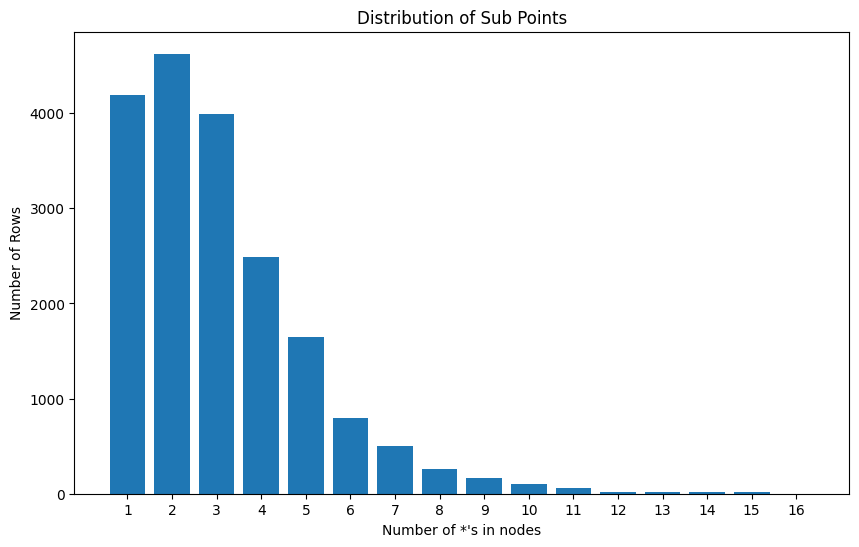

In [115]:
import matplotlib.pyplot as plt

# Function to count '*' in the 'nodes' column
def count_stars(nodes):
    nodes_str = str(nodes)  # Convert list of tuples to string
    return nodes_str.count('*')

# Apply function to replace 'sub_points' with the count of '*'
df_rings['sub_points'] = df_rings['nodes'].apply(count_stars)

# Count occurrences of each sub_points value
sub_points_counts = df_rings['sub_points'].value_counts().sort_index()

# Plot the distribution
plt.figure(figsize=(10, 6))
plt.bar(sub_points_counts.index, sub_points_counts.values)
plt.xlabel("Number of *'s in nodes")
plt.ylabel("Number of Rows")
plt.title("Distribution of Sub Points")
plt.xticks(range(sub_points_counts.index.min(), sub_points_counts.index.max() + 1))  # Ensure all x-ticks are shown
plt.show()


In [116]:
import re

# Function to clean 'nodes' column
def clean_nodes(nodes):
    return str(nodes).replace("'", "")  # Remove all single quotes

# Function to clean 'edges' column
def clean_edges(edges):
    edges_str = str(edges)  # Convert to string
    edges_str = edges_str.replace(":", ",")  # Replace colons with commas
    edges_str = re.sub(r"'(.*?)'", r"(\1)", edges_str)  # Replace single quotes with parentheses
    edges_str = edges_str.upper()  # Convert text to uppercase
    return edges_str

# Apply transformations to df_rings
df_rings['nodes'] = df_rings['nodes'].apply(clean_nodes)
df_rings['edges'] = df_rings['edges'].apply(clean_edges)

# Display the updated DataFrame
print(df_rings)


                                                   nodes  \
0      [(2, C*), (3, C), (4, C), (5, C*), (43, C), (4...   
1      [(7, C*), (8, C), (9, C), (10, C), (11, C), (1...   
2      [(5, C*), (6, C), (7, C), (8, C), (9, C), (10,...   
3      [(2, C*), (3, C), (4, C), (5, C), (6, C*), (27...   
4      [(42, C), (43, C), (44, S), (14, C*), (15, C),...   
...                                                  ...   
18891  [(1, C*), (2, N), (3, C*), (5, C), (6, C), (7,...   
18892  [(1, C*), (2, N), (3, C), (4, C), (5, C), (6, ...   
18893  [(1, C*), (2, N), (3, C), (4, C), (5, C), (6, ...   
18894  [(1, C*), (2, N), (3, C*), (5, C), (6, C), (7,...   
18895  [(1, C*), (2, N), (3, C*), (5, C), (6, C), (7,...   

                                                   edges parent_db  \
0      [(2,3, AROMATIC), (2,44, AROMATIC), (3,4, AROM...   d3tales   
1      [(7,8, AROMATIC), (7,12, AROMATIC), (8,9, AROM...   d3tales   
2      [(5,6, AROMATIC), (5,10, AROMATIC), (6,7, AROM...   d3tales   

In [117]:
# Rename the column 'subgraph_smiles' to 'smiles'
df_rings = df_rings.rename(columns={'subgraph_smiles': 'smiles'})

# Display the updated DataFrame
print(df_rings)


                                                   nodes  \
0      [(2, C*), (3, C), (4, C), (5, C*), (43, C), (4...   
1      [(7, C*), (8, C), (9, C), (10, C), (11, C), (1...   
2      [(5, C*), (6, C), (7, C), (8, C), (9, C), (10,...   
3      [(2, C*), (3, C), (4, C), (5, C), (6, C*), (27...   
4      [(42, C), (43, C), (44, S), (14, C*), (15, C),...   
...                                                  ...   
18891  [(1, C*), (2, N), (3, C*), (5, C), (6, C), (7,...   
18892  [(1, C*), (2, N), (3, C), (4, C), (5, C), (6, ...   
18893  [(1, C*), (2, N), (3, C), (4, C), (5, C), (6, ...   
18894  [(1, C*), (2, N), (3, C*), (5, C), (6, C), (7,...   
18895  [(1, C*), (2, N), (3, C*), (5, C), (6, C), (7,...   

                                                   edges parent_db  \
0      [(2,3, AROMATIC), (2,44, AROMATIC), (3,4, AROM...   d3tales   
1      [(7,8, AROMATIC), (7,12, AROMATIC), (8,9, AROM...   d3tales   
2      [(5,6, AROMATIC), (5,10, AROMATIC), (6,7, AROM...   d3tales   

In [130]:
print(df_rings)
print(sc_df)

                                                   nodes  \
0      [(2, C*), (3, C), (4, C), (5, C*), (43, C), (4...   
1      [(7, C*), (8, C), (9, C), (10, C), (11, C), (1...   
2      [(5, C*), (6, C), (7, C), (8, C), (9, C), (10,...   
3      [(2, C*), (3, C), (4, C), (5, C), (6, C*), (27...   
4      [(42, C), (43, C), (44, S), (14, C*), (15, C),...   
...                                                  ...   
18479  [(1, C*), (2, N), (3, C*), (5, C), (6, C), (7,...   
18480  [(1, C*), (2, N), (3, C), (4, C), (5, C), (6, ...   
18481  [(1, C*), (2, N), (3, C), (4, C), (5, C), (6, ...   
18482  [(1, C*), (2, N), (3, C*), (5, C), (6, C), (7,...   
18483  [(1, C*), (2, N), (3, C*), (5, C), (6, C), (7,...   

                                                   edges        parent_db  \
0      [(2,3, AROMATIC), (2,44, AROMATIC), (3,4, AROM...  ocelot, d3tales   
1      [(7,8, AROMATIC), (7,12, AROMATIC), (8,9, AROM...  ocelot, d3tales   
2      [(5,6, AROMATIC), (5,10, AROMATIC), (6,7,

In [119]:
print(df_rings.dtypes)

nodes                object
edges                object
parent_db            object
id                   object
sub_points            int64
smiles               object
atom_C               object
atom_S               object
atom_N               object
atom_O               object
atom_B               object
rings                object
atom_H               object
atoms_total          object
methylated_smiles    object
rings_minimal        object
atom_P               object
atom_Se              object
atom_Te              object
atom_Si              object
atom_As              object
dtype: object


In [120]:
print(sc_df.dtypes)


smiles    object
nodes     object
edges     object
id        object
dtype: object


In [121]:
# import pandas as pd
# 
# # Function to ensure uniform string conversion
# def force_string_conversion(value):
#     return str(value)  # Explicitly force to string
# 
# # Apply explicit string conversion to both DataFrames
# df_rings['nodes'] = df_rings['nodes'].apply(force_string_conversion)
# df_rings['edges'] = df_rings['edges'].apply(force_string_conversion)
# 
# sc_df['nodes'] = sc_df['nodes'].apply(force_string_conversion)
# sc_df['edges'] = sc_df['edges'].apply(force_string_conversion)
# 
# # Print confirmation
# print("Nodes and edges columns in both DataFrames have been explicitly converted to uniform strings.")


In [122]:
# # Function to force a consistent string format using repr()
# def force_consistent_format(value):
#     return repr(value)  # Ensures identical string representation
# 
# # Apply explicit formatting to both DataFrames
# df_rings['nodes'] = df_rings['nodes'].apply(force_consistent_format)
# df_rings['edges'] = df_rings['edges'].apply(force_consistent_format)
# 
# sc_df['nodes'] = sc_df['nodes'].apply(force_consistent_format)
# sc_df['edges'] = sc_df['edges'].apply(force_consistent_format)
# 
# # Print confirmation
# print("Nodes and edges columns in both DataFrames have been explicitly converted to uniform strings using repr().")


In [209]:
import ast

# Function to safely convert stringified lists into actual lists
def safe_eval(value):
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)  # Convert back to a list if it was stored as a string
        except (ValueError, SyntaxError):
            return value  # Keep it as is if it fails
    return value  # If it's already a list, return as is

# Apply the fix to ensure both DataFrames store lists correctly
df_rings['nodes'] = df_rings['nodes'].apply(safe_eval)
df_rings['edges'] = df_rings['edges'].apply(safe_eval)

sc_df['nodes'] = sc_df['nodes'].apply(safe_eval)
sc_df['edges'] = sc_df['edges'].apply(safe_eval)

# Print confirmation
print("Nodes and edges columns in both DataFrames have been converted to proper lists.")


Nodes and edges columns in both DataFrames have been converted to proper lists.


In [210]:
print(df_rings)
print(sc_df)

                                               nodes  \
0      [(1, C*), (2, N), (3, C*), (5, N*), (12, N*)]   
1  [(4, C*), (5, C), (6, C), (7, C), (8, C), (9, ...   
2  [(1, C*), (2, N), (3, C), (4, C), (5, S), (6, ...   
3  [(4, C*), (5, C*), (12, C*), (15, C), (16, O),...   
4  [(4, C*), (5, C), (6, N), (7, C), (8, C), (9, ...   

                                               edges parent_db  \
0  [(1,2, SINGLE), (1,12, SINGLE), (2,3, SINGLE),...   d3tales   
1  [(4,5, AROMATIC), (4,9, AROMATIC), (5,6, AROMA...    ocelot   
2  [(1,2, SINGLE), (1,6, SINGLE), (2,3, SINGLE), ...   d3tales   
3  [(4,5, DOUBLE), (4,17, SINGLE), (5,12, SINGLE)...   d3tales   
4  [(4,5, DOUBLE), (4,14, SINGLE), (5,6, SINGLE),...   d3tales   

                                                  id  sub_points  \
0  9b0a10d61801b9ca1d01ec9eafe00f9b7f410bc0190bb8...           4   
1  e45d62a6c32cc6ae518438d2e4921016afa4b06dc9747e...           2   
2  f6b2f7688ae5b77ec07caffb2aacaf87f7b0522eeff8c3...          

In [125]:
# Identify duplicate IDs
duplicate_ids = df_rings[df_rings.duplicated(subset=['id'], keep=False)]['id'].unique()

# Update parent_db for duplicate rows
df_rings.loc[df_rings['id'].isin(duplicate_ids), 'parent_db'] = "ocelot, d3tales"

# Drop duplicate rows, keeping only one occurrence per ID
df_rings = df_rings.drop_duplicates(subset=['id'], keep='first')

# Print confirmation
print("Duplicates removed, and parent_db updated for duplicate IDs.")


Duplicates removed, and parent_db updated for duplicate IDs.


In [128]:
import pandas as pd

# Ensure 'nodes' and 'edges' are stored as strings before saving
df_rings['nodes'] = df_rings['nodes'].apply(lambda x: str(x))
df_rings['edges'] = df_rings['edges'].apply(lambda x: str(x))

sc_df['nodes'] = sc_df['nodes'].apply(lambda x: str(x))
sc_df['edges'] = sc_df['edges'].apply(lambda x: str(x))

# Define file paths
rings_path = r"C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination\data\ring_db.parquet"
sidechains_path = r"C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination\data\sidechain_db.parquet"

# Save DataFrames as Parquet files
df_rings.to_parquet(rings_path, index=False)
sc_df.to_parquet(sidechains_path, index=False)

print("Parquet files saved successfully as ring_db.parquet and sidechain_db.parquet!")


Parquet files saved successfully as ring_db.parquet and sidechain_db.parquet!


In [149]:
import pandas as pd

# Define file paths
rings_path = r"C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination\data\ring_db.parquet"
sidechains_path = r"C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination\data\sidechain_db.parquet"

rings_test_path = r"C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination\data\ring_db_test.parquet"
sidechains_test_path = r"C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination\data\sidechain_db_test.parquet"

# Load Parquet files into temporary DataFrames (DOES NOT MODIFY ORIGINALS)
df_rings = pd.read_parquet(rings_path)
sc_df = pd.read_parquet(sidechains_path)

# Ensure 'sub_points' is numeric for filtering
df_rings['sub_points'] = pd.to_numeric(df_rings['sub_points'], errors='coerce')

# Create a temporary filtered copy where sub_points is between 2 and 4
filtered_rings = df_rings[(df_rings['sub_points'] >= 2) & (df_rings['sub_points'] <= 4)].copy()

# Sample up to 5 rows from the filtered data (ensures we don’t error out)
rings_test = filtered_rings.sample(n=min(5, len(filtered_rings)), random_state=42)
sidechains_test = sc_df.sample(n=min(5, len(sc_df)), random_state=42)

# Save test datasets as Parquet files (DOES NOT MODIFY ORIGINALS)
rings_test.to_parquet(rings_test_path, index=False)
sidechains_test.to_parquet(sidechains_test_path, index=False)

print("Test datasets saved successfully as ring_db_test.parquet and sidechain_db_test.parquet!")


Test datasets saved successfully as ring_db_test.parquet and sidechain_db_test.parquet!


In [150]:
import pandas as pd

# Define file paths
sidechains_file = r"C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination\data\sidechain_db_test.parquet"
rings_file = r"C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination\data\ring_db_test.parquet"

# Load Parquet files into Pandas DataFrames
df_sidechains = pd.read_parquet(sidechains_file)
df_rings = pd.read_parquet(rings_file)

# Display the first few rows of each DataFrame
print("Combinations DataFrame:")
print(df_sidechains)

print("\nRings DataFrame:")
print(df_rings)

Combinations DataFrame:
      smiles                                              nodes  \
0   c1ccccn1  [(4, 'C'), (1, 'C*'), (6, 'N'), (2, 'C'), (3, ...   
1          S                                        [(0, 'S*')]   
2  O=P(O)(O)          [(0, 'O'), (2, 'O'), (3, 'O'), (1, 'P*')]   
3    O=N(=O)                    [(0, 'O'), (2, 'O'), (1, 'N*')]   
4   c1ccccc1  [(6, 'C'), (4, 'C'), (1, 'C*'), (2, 'C'), (3, ...   

                                               edges  \
0  [(1, 2, 'AROMATIC'), (1, 6, 'AROMATIC'), (2, 3...   
1                                                 []   
2  [(0, 1, 'DOUBLE'), (1, 2, 'SINGLE'), (1, 3, 'S...   
3               [(0, 1, 'SINGLE'), (1, 2, 'DOUBLE')]   
4  [(1, 2, 'AROMATIC'), (1, 6, 'AROMATIC'), (2, 3...   

                                                  id  
0  d7b9006fbfa108abc4bbd79f01eff1675e90457a9da7f7...  
1  aac97681786b3509967de1b9d0677160b6593480a27671...  
2  e081b2e90b1d2d7fcac96ea294c65e811c67909c79a0d5...  
3  8013e49b59cb4

## Compute the combinations database
### this will have columns: id_ring, id_sidechain, id, smiles, selfies, xyz, fp_morgan, fp_rdkit, fp_atompair, fp_toptorsion. 
### initialize everything with N/A, number id from 0,1,2,3,4, …

In [152]:
import duckdb
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path
import itertools
import os


class GenComs_Ring_Sidechains:
    def __init__(self, ring_file, sidechain_file, output_dir):
        """
        Initializes the class with input ring and sidechain datasets and the output directory.
        The Parquet file name will be automatically determined to avoid overwrites.
        """
        self.ring_file = ring_file
        self.sidechain_file = sidechain_file
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.output_file = self.get_unique_filename()
        self.con = duckdb.connect()

    def get_unique_filename(self):
        """
        Generate a unique Parquet filename by appending _1, _2, etc., if a file already exists.
        """
        base_filename = "combinations"
        extension = ".parquet"
        output_path = self.output_dir / f"{base_filename}{extension}"

        counter = 1
        while output_path.exists():
            output_path = self.output_dir / f"{base_filename}_{counter}{extension}"
            counter += 1

        return output_path

    def load_data(self):
        """
        Loads ring and sidechain datasets into DuckDB tables.
        """
        self.con.execute(f"CREATE TABLE rings AS SELECT * FROM '{self.ring_file}'")
        self.con.execute(f"CREATE TABLE sidechains AS SELECT * FROM '{self.sidechain_file}'")

    def ensure_valid_parquet(self):
        """
        Ensures that the output Parquet file is valid by creating an empty file with the correct schema if needed.
        """
        parquet_schema = pa.schema([
            ("id", pa.int32()),  # Unique combination ID
            ("id_ring", pa.string()),  # Ring ID
            ("id_sidechain", pa.list_(pa.string())),  # List of sidechain IDs
            ("smiles", pa.string()),  # Placeholder
            ("selfies", pa.string()),  # Placeholder
            ("xyz", pa.string()),  # Placeholder
            ("fp_morgan", pa.string()),  # Placeholder
            ("fp_rdkit", pa.string()),  # Placeholder
            ("fp_atompair", pa.string()),  # Placeholder
            ("fp_toptorsion", pa.string())  # Placeholder
        ])

        # If the file does not exist or is empty, create a valid empty Parquet file
        if not os.path.exists(self.output_file) or os.path.getsize(self.output_file) == 0:
            print(f"Initializing {self.output_file} with an empty valid schema.")
            empty_table = pa.Table.from_pandas(pd.DataFrame(columns=parquet_schema.names), schema=parquet_schema)
            pq.write_table(empty_table, self.output_file)

    def generate_combinations(self):
        """
        Processes rings one at a time, generating all possible sidechain combinations
        (including repeated sidechains) based on the number of substitution points.
        Saves results to the Parquet file iteratively.
        """
        # Ensure output file is valid before writing
        self.ensure_valid_parquet()

        # Read existing combinations to determine the starting ID
        try:
            existing_table = pq.read_table(self.output_file)
            existing_df = existing_table.to_pandas()
            next_id = existing_df["id"].max() + 1 if not existing_df.empty else 0
        except:
            next_id = 0

        # Read rings and sidechains tables into DuckDB
        rings_df = self.con.execute("SELECT * FROM rings").fetchdf()
        sidechains_df = self.con.execute("SELECT * FROM sidechains").fetchdf()

        # Define the output Parquet schema
        parquet_schema = pa.schema([
            ("id", pa.int32()),  # Unique combination ID
            ("id_ring", pa.string()),  # Ring ID
            ("id_sidechain", pa.list_(pa.string())),  # List of sidechain IDs
            ("smiles", pa.string()),  # Placeholder
            ("selfies", pa.string()),  # Placeholder
            ("xyz", pa.string()),  # Placeholder
            ("fp_morgan", pa.string()),  # Placeholder
            ("fp_rdkit", pa.string()),  # Placeholder
            ("fp_atompair", pa.string()),  # Placeholder
            ("fp_toptorsion", pa.string())  # Placeholder
        ])

        # Process one ring at a time
        for _, ring in rings_df.iterrows():
            ring_id = ring["id"]
            n_subs = ring["sub_points"]

            # Generate all possible combinations of `n_subs` sidechains (including repetitions)
            sidechain_combinations = list(itertools.product(sidechains_df.itertuples(index=False), repeat=n_subs))

            results = []
            for sidechain_set in sidechain_combinations:
                sub_ids = [sc.id for sc in sidechain_set]

                # Construct a row with ordered lists
                row = {
                    "id": next_id,  # Unique combination ID
                    "id_ring": str(ring_id),
                    "id_sidechain": sub_ids,  # List of sidechain IDs
                    "smiles": "N/A",  # Placeholder
                    "selfies": "N/A",
                    "xyz": "N/A",
                    "fp_morgan": "N/A",
                    "fp_rdkit": "N/A",
                    "fp_atompair": "N/A",
                    "fp_toptorsion": "N/A"
                }
                results.append(row)
                next_id += 1  # Increment the ID

            # Convert results to a DataFrame
            df_combinations = pd.DataFrame(results,
                                           columns=["id", "id_ring", "id_sidechain", "smiles", "selfies",
                                                    "xyz", "fp_morgan", "fp_rdkit", "fp_atompair", "fp_toptorsion"])

            # Append to Parquet file manually
            if not df_combinations.empty:
                # Read the existing Parquet file
                existing_table = pq.read_table(self.output_file)

                # Convert DataFrame to Arrow Table with the same schema
                new_table = pa.Table.from_pandas(df_combinations, schema=parquet_schema)

                # Concatenate existing and new tables
                combined_table = pa.concat_tables([existing_table, new_table])

                # Write back to Parquet file
                pq.write_table(combined_table, self.output_file)

            print(f"Processed ring {ring_id} with {n_subs} substituent positions.")

    def close_connection(self):
        """
        Closes the DuckDB connection.
        """
        self.con.close()


# Example usage
if __name__ == "__main__":
    # Define file paths
    HOME_DIR = Path.cwd()
    ring_file = HOME_DIR/ "ring_db_test.parquet"
    sidechain_file = HOME_DIR/ "sidechain_db_test.parquet"
    output_dir = HOME_DIR / "output"  # Store files in an output directory

    # Initialize and run the class
    generator = GenComs_Ring_Sidechains(ring_file, sidechain_file, output_dir)
    generator.load_data()
    generator.generate_combinations()
    generator.close_connection()


Initializing C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination\data\output\combinations.parquet with an empty valid schema.
Processed ring 9b0a10d61801b9ca1d01ec9eafe00f9b7f410bc0190bb8059f3ede82a4aa03a4 with 4 substituent positions.
Processed ring e45d62a6c32cc6ae518438d2e4921016afa4b06dc9747ec4e687c32e16715ceb with 2 substituent positions.
Processed ring f6b2f7688ae5b77ec07caffb2aacaf87f7b0522eeff8c30a94e9e83f7b82b3a4 with 2 substituent positions.
Processed ring 32e1a6871503f1c1378aa31f0df6e9025465a60e3f145de566e1d60608c69614 with 4 substituent positions.
Processed ring 9fd24e97c705cbeb64a5970f89aa2b61627ee984c9f061385503f0e3ed0d66fc with 3 substituent positions.


In [163]:
import pandas as pd

# Define the file path
file_path = r"C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination\data\output\combinations.parquet"

# Load the Parquet file
df_combinations = pd.read_parquet(file_path)

# Display the DataFrame
print(df_combinations)


        id                                            id_ring  \
0        0  9b0a10d61801b9ca1d01ec9eafe00f9b7f410bc0190bb8...   
1        1  9b0a10d61801b9ca1d01ec9eafe00f9b7f410bc0190bb8...   
2        2  9b0a10d61801b9ca1d01ec9eafe00f9b7f410bc0190bb8...   
3        3  9b0a10d61801b9ca1d01ec9eafe00f9b7f410bc0190bb8...   
4        4  9b0a10d61801b9ca1d01ec9eafe00f9b7f410bc0190bb8...   
...    ...                                                ...   
1420  1420  9fd24e97c705cbeb64a5970f89aa2b61627ee984c9f061...   
1421  1421  9fd24e97c705cbeb64a5970f89aa2b61627ee984c9f061...   
1422  1422  9fd24e97c705cbeb64a5970f89aa2b61627ee984c9f061...   
1423  1423  9fd24e97c705cbeb64a5970f89aa2b61627ee984c9f061...   
1424  1424  9fd24e97c705cbeb64a5970f89aa2b61627ee984c9f061...   

                                           id_sidechain       smiles selfies  \
0     [d7b9006fbfa108abc4bbd79f01eff1675e90457a9da7f...  in_progress     N/A   
1     [d7b9006fbfa108abc4bbd79f01eff1675e90457a9da7f...    

## Combine SMILEs one row at a time for ease of multiprocessing
### Use combined_1 dataset
### grab first row with N/A in the smiles column
### replace smiles with ‘in_progress’
### compute combined smiles
### replace value in the same row of the smiles column with the new computed combined smiles

In [156]:
import duckdb

# Define file paths
ring_file = "ring_db_test.parquet"
sidechain_file = "sidechain_db_test.parquet"
combinations_file = "output/combinations.parquet"

# Connect to DuckDB
con = duckdb.connect()

# Query to locate the first row in combinations that contains "N/A"
query = f"""
    SELECT * FROM '{combinations_file}'
    WHERE smiles = 'N/A' OR selfies = 'N/A' OR xyz = 'N/A' 
        OR fp_morgan = 'N/A' OR fp_rdkit = 'N/A' 
        OR fp_atompair = 'N/A' OR fp_toptorsion = 'N/A'
    LIMIT 1;
"""

# Execute the query and fetch the result
result = con.execute(query).fetchdf()

# Print the first row with "N/A"
print(result)

# Close the DuckDB connection
con.close()


   id                                            id_ring  \
0   0  9b0a10d61801b9ca1d01ec9eafe00f9b7f410bc0190bb8...   

                                        id_sidechain smiles selfies  xyz  \
0  [d7b9006fbfa108abc4bbd79f01eff1675e90457a9da7f...    N/A     N/A  N/A   

  fp_morgan fp_rdkit fp_atompair fp_toptorsion  
0       N/A      N/A         N/A           N/A  


In [162]:
import duckdb

# Define file paths
combinations_file = "output/combinations.parquet"

# Connect to DuckDB
con = duckdb.connect()

# Locate the first row where "smiles" is "N/A"
query = f"""
    SELECT * FROM read_parquet('{combinations_file}')
    WHERE smiles = 'N/A'
    LIMIT 1;
"""

# Fetch the first row with "N/A" in smiles
result = con.execute(query).fetchdf()

# If a row was found, update only "smiles" in that row
if not result.empty:
    row_id = result["id"].iloc[0]  # Get the ID of the row

    # Create a modified version of the table with correctly updated "smiles" column
    update_query = f"""
        CREATE TABLE updated_combinations AS
        SELECT id, id_ring, id_sidechain, 
               CASE 
                   WHEN id = {row_id} THEN 'in_progress'
                   ELSE smiles 
               END AS smiles,
               selfies, xyz, fp_morgan, fp_rdkit, fp_atompair, fp_toptorsion
        FROM read_parquet('{combinations_file}');
    """

    # Execute the update by creating a modified table
    con.execute(update_query)

    # Overwrite the original Parquet file with the updated table
    con.execute(f"COPY updated_combinations TO '{combinations_file}' (FORMAT PARQUET);")

    print(f"Updated row with id={row_id}, setting 'N/A' to 'in_progress' in smiles.")

# Close the DuckDB connection
con.close()


Updated row with id=0, setting 'N/A' to 'in_progress' in smiles.


In [166]:
import duckdb
import ast
import networkx as nx
from rdkit import Chem

class MoleculeReconstructor:
    def __init__(self, combinations_file, rings_file, substituents_file):
        self.combinations_file = combinations_file
        self.rings_file = rings_file
        self.substituents_file = substituents_file

    @staticmethod
    def parse_nodes(nodes):
        """Converts node string to list of tuples (index, label)."""
        if isinstance(nodes, str):
            try:
                nodes = ast.literal_eval(nodes)
            except (SyntaxError, ValueError):
                return []
        return [(int(idx), str(label)) for idx, label in nodes if isinstance(idx, int) and isinstance(label, str)]

    @staticmethod
    def parse_edges(edges):
        """Converts edge data to list of tuples (node1, node2, bond type)."""
        if isinstance(edges, str):
            try:
                return ast.literal_eval(edges)
            except (SyntaxError, ValueError):
                return []
        return edges if isinstance(edges, list) else []

    def extract_G(self):
        """Extracts the molecular graph for the first row where `smiles` is 'in_progress'."""
        con = duckdb.connect()
        row_query = f"""
            SELECT * FROM read_parquet('{self.combinations_file}')
            WHERE smiles = 'in_progress'
            LIMIT 1;
        """
        row_data = con.execute(row_query).fetchdf()

        if row_data.empty:
            print("No 'in_progress' row found in combinations.")
            return None, None, None, None

        row_id = row_data["id"].iloc[0]
        ring_id = row_data["id_ring"].iloc[0]
        sub_ids = row_data["id_sidechain"].iloc[0]

        # Retrieve the ring graph data
        ring_query = f"SELECT nodes, edges FROM read_parquet('{self.rings_file}') WHERE id = ?;"
        ring_data = con.execute(ring_query, [ring_id]).fetchdf()

        if ring_data.empty:
            print(f"Ring {ring_id} not found.")
            return None, None, None, None

        ring_nodes = self.parse_nodes(ring_data["nodes"].iloc[0])
        ring_edges = self.parse_edges(ring_data["edges"].iloc[0])

        # Retrieve sidechain data
        sidechains = []
        for sub_id in sub_ids:
            sub_query = f"SELECT nodes, edges FROM read_parquet('{self.substituents_file}') WHERE id = ?;"
            sub_data = con.execute(sub_query, [sub_id]).fetchdf()

            if sub_data.empty:
                print(f"Substituent {sub_id} not found.")
                continue

            sub_nodes = self.parse_nodes(sub_data["nodes"].iloc[0])
            sub_edges = self.parse_edges(sub_data["edges"].iloc[0])
            sidechains.append((sub_nodes, sub_edges))

        con.close()

        return row_id, ring_nodes, ring_edges, sidechains

    @staticmethod
    def renumber_nodes(ring_nodes, ring_edges, sidechains):
        """Renumbers nodes sequentially and ensures valid connectivity."""
        node_map = {}
        new_nodes = []
        new_edges = []

        current_index = 0
        for old_idx, label in ring_nodes:
            node_map[old_idx] = current_index
            new_nodes.append((current_index, label))
            current_index += 1

        for node1, node2, bond in ring_edges:
            new_edges.append((node_map[node1], node_map[node2], bond))

        renumbered_sidechains = []
        for sub_nodes, sub_edges in sidechains:
            sub_node_map = {}
            new_sub_nodes = []
            new_sub_edges = []

            for old_idx, label in sub_nodes:
                sub_node_map[old_idx] = current_index
                new_sub_nodes.append((current_index, label))
                current_index += 1

            for node1, node2, bond in sub_edges:
                new_sub_edges.append((sub_node_map[node1], sub_node_map[node2], bond))

            renumbered_sidechains.append((new_sub_nodes, new_sub_edges))

        return new_nodes, new_edges, renumbered_sidechains

    @staticmethod
    def bind_sc_rings(ring_nodes, ring_edges, sidechains):
        """Builds a molecular graph and connects ring and sidechains correctly."""
        G = nx.Graph()
        node_map = {}
        current_index = 0

        ring_star_nodes = []
        for old_idx, label in ring_nodes:
            node_map[old_idx] = current_index
            G.add_node(current_index, label=label)
            if '*' in label:
                ring_star_nodes.append(current_index)
            current_index += 1

        for n1, n2, bond in ring_edges:
            G.add_edge(node_map[n1], node_map[n2], bond=bond)

        sidechain_mappings = []
        for sub_nodes, sub_edges in sidechains:
            sub_node_map = {}
            sub_star_nodes = []
            for old_idx, label in sub_nodes:
                sub_node_map[old_idx] = current_index
                G.add_node(current_index, label=label)
                if '*' in label:
                    sub_star_nodes.append(current_index)
                current_index += 1

            sidechain_mappings.append((sub_node_map, sub_star_nodes))
            for n1, n2, bond in sub_edges:
                G.add_edge(sub_node_map[n1], sub_node_map[n2], bond=bond)

        for sub_node_map, sub_star_nodes in sidechain_mappings:
            if not ring_star_nodes or not sub_star_nodes:
                continue
            ring_star = ring_star_nodes.pop(0)
            sidechain_star = sub_star_nodes.pop(0)
            G.add_edge(ring_star, sidechain_star, bond='Single')
            G.nodes[ring_star]['label'] = G.nodes[ring_star]['label'].replace('*', '', 1)
            G.nodes[sidechain_star]['label'] = G.nodes[sidechain_star]['label'].replace('*', '', 1)

        return G
    
    @staticmethod
    def G_to_smi(G):
        """Converts a NetworkX molecular graph into an RDKit SMILES string."""
        mol = Chem.RWMol()
        atom_map = {}

        # Add atoms to RDKit molecule
        for idx, label in G.nodes(data="label"):
            atom_symbol = label.replace('*', '')  # Ensure '*' is removed before adding atoms
            atom = Chem.Atom(atom_symbol)
            atom_idx = mol.AddAtom(atom)
            atom_map[idx] = atom_idx  # Track mapping

        # Add bonds to RDKit molecule
        bond_dict = {'Single': Chem.BondType.SINGLE, 'Double': Chem.BondType.DOUBLE, 'Aromatic': Chem.BondType.AROMATIC}
        
        for n1, n2, bond in G.edges(data="bond"):
            mol.AddBond(atom_map[n1], atom_map[n2], bond_dict.get(bond, Chem.BondType.SINGLE))

        # Convert to SMILES
        smiles = Chem.MolToSmiles(mol, canonical=True)
        return smiles

    def reconstruct(self):
        """Runs the reconstruction process and updates the first 'in_progress' row."""
        row_id, ring_nodes, ring_edges, sidechains = self.extract_G()
        if ring_nodes is None:
            return "Failed to extract molecular graph."

        new_ring_nodes, new_ring_edges, renumbered_sidechains = self.renumber_nodes(ring_nodes, ring_edges, sidechains)
        G = self.bind_sc_rings(new_ring_nodes, new_ring_edges, renumbered_sidechains)
        final_smiles = self.G_to_smi(G)

        with duckdb.connect() as con:
            update_query = f"""
                CREATE TABLE updated_combinations AS
                SELECT *,
                    CASE 
                        WHEN id = {row_id} THEN '{final_smiles}'
                        ELSE smiles 
                    END AS smiles
                FROM read_parquet('{self.combinations_file}');
            """
            con.execute(update_query)
            con.execute(f"COPY updated_combinations TO '{self.combinations_file}' (FORMAT PARQUET);")

        print(f"Updated row with id={row_id}, setting 'smiles' to: {final_smiles}")
        return final_smiles



# **Usage Example**
if __name__ == "__main__":
    combinations_file = r"C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination\data\output\combinations.parquet"
    rings_file = r"C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination\data\ring_db_test.parquet"
    substituents_file = r"C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination\data\sidechain_db_test.parquet"

    reconstructor = MoleculeReconstructor(combinations_file, rings_file, substituents_file)
    final_smiles = reconstructor.reconstruct()
    print("Final SMILES:", final_smiles)


Updated row with id=0, setting 'smiles' to: C1CCNCC1.C1CCNCC1.C1CCNCC1.C1CCNCC1
Final SMILES: C1CCNCC1.C1CCNCC1.C1CCNCC1.C1CCNCC1


In [178]:
import os
import multiprocessing

def get_processor_count():
    try:
        # Get the number of available logical processors
        cpu_count = os.cpu_count()  # Works on Windows, Linux, macOS
        # Get the number of available physical cores (if possible)
        physical_cores = multiprocessing.cpu_count()
        
        print(f"Logical processors available: {cpu_count}")
        print(f"Physical cores available: {physical_cores}")

    except Exception as e:
        print(f"Error retrieving processor count: {e}")

if __name__ == "__main__":
    get_processor_count()


Logical processors available: 8
Physical cores available: 8


## New Approach Utilizing a SLURM Queue System

In [184]:
import os

new_path = r"C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination"  # Replace with your actual path
os.chdir(new_path)

print("Current working directory:", os.getcwd())  # Verify the change

Current working directory: C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination


In [185]:
import os
print(f"Current working directory: {os.getcwd()}")

Current working directory: C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination


In [195]:
import os
import multiprocessing
import pandas as pd
import pyarrow as pa  # Importing pyarrow directly
import pyarrow.parquet as pq

def get_slurm_processors(max_cpus=4):
    """Determine the number of processors allocated by SLURM, but limit to max_cpus."""
    slurm_cpus = os.getenv("SLURM_CPUS_ON_NODE")
    available_cpus = int(slurm_cpus) if slurm_cpus else multiprocessing.cpu_count()

    # Ensure we do not exceed max_cpus
    nproc = min(available_cpus, max_cpus)
    return nproc

def split_parquet(input_parquet, output_prefix, nproc):
    """Split a Parquet file into nproc smaller Parquet files."""
    table = pq.read_table(input_parquet)
    df = table.to_pandas()
    split_dfs = [df.iloc[i::nproc] for i in range(nproc)]
    
    for i, split_df in enumerate(split_dfs, 1):
        pq.write_table(pa.Table.from_pandas(split_df), f"{output_prefix}_{i}.parquet")  # ✅ Use pa.Table
        print(f"Written: {output_prefix}_{i}.parquet")

if __name__ == "__main__":
    nproc = get_slurm_processors(max_cpus=4)  # Set max CPUs to 4
    print(f"Using {nproc} processors for splitting.")

    split_parquet("ring.parquet", "ring", nproc)

    # Load all ring files and sidechain into memory
    ring_data = {i: pq.read_table(f"ring_{i}.parquet").to_pandas() for i in range(1, nproc + 1)}
    sidechain_data = pq.read_table("sidechain.parquet").to_pandas()

    print("All data loaded into memory.")
import sys
import duckdb
import pyarrow.parquet as pq
from pathlib import Path

class GenComs_Ring_Sidechains:
    def __init__(self, procnumber, sidechain_file, output_dir):
        """
        Initializes the class with input processor-specific ring and sidechain datasets.
        """
        self.procnumber = procnumber
        self.ring_file = f"ring_{procnumber}.parquet"  # Processor-specific ring file
        self.sidechain_file = sidechain_file
        self.output_dir = Path(output_dir)
        self.output_file = self.output_dir / f"combinations_{procnumber}.parquet"

        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.con = duckdb.connect(database=f"combinations_{procnumber}.db", read_only=False)

    def load_data(self):
        """
        Loads ring and sidechain datasets into DuckDB tables.
        """
        self.con.execute(f"CREATE TABLE rings AS SELECT * FROM '{self.ring_file}'")
        self.con.execute(f"CREATE TABLE sidechains AS SELECT * FROM '{self.sidechain_file}'")

    def generate_combinations(self):
        """
        Processes rings one at a time, generating all possible sidechain combinations.
        Saves results to a DuckDB-managed Parquet file.
        """
        # Perform a CROSS JOIN using DuckDB (efficient for large datasets)
        self.con.execute("""
            CREATE TABLE IF NOT EXISTS combinations AS
            SELECT * FROM rings CROSS JOIN sidechains;
        """)
        
        # Save to parquet (large dataset, avoid keeping it in memory)
        self.con.execute(f"COPY combinations TO '{self.output_file}' (FORMAT 'parquet');")

        print(f"Generated: {self.output_file}")

    def close_connection(self):
        """Closes the DuckDB connection."""
        self.con.close()


if __name__ == "__main__":
    # Ensure we have a valid integer argument for procnumber
    try:
        procnumber = int(sys.argv[1]) if len(sys.argv) > 1 and sys.argv[1].isdigit() else 1  # Default to 1
    except ValueError:
        print(f"Invalid argument: {sys.argv[1]}. Defaulting to procnumber=1")
        procnumber = 1  # Fallback

    sidechain_file = "testing/sidechain.parquet"  # Sidechains are the same for all processes
    output_dir = "output"

    generator = GenComs_Ring_Sidechains(procnumber, sidechain_file, output_dir)
    generator.load_data()
    generator.generate_combinations()
    generator.close_connection()


Using 4 processors for splitting.
Written: ring_1.parquet
Written: ring_2.parquet
Written: ring_3.parquet
Written: ring_4.parquet
All data loaded into memory.
Generated: output\combinations_1.parquet


In [ ]:
import sys
import pyarrow.parquet as pq
import duckdb

def build_from_combinations(procnumber):
    """Process combinations using DuckDB."""
    ring_df = pq.read_table(f"ring_{procnumber}.parquet").to_pandas()
    sidechain_df = pq.read_table("sidechain.parquet").to_pandas()

    con = duckdb.connect(database=f"combinations_{procnumber}.db", read_only=False)
    
    con.execute(f"""
        CREATE TABLE IF NOT EXISTS processed_combinations AS
        SELECT * FROM combinations
        WHERE EXISTS (SELECT 1 FROM sidechain_df WHERE combinations.some_column = sidechain_df.some_column);
    """)
    
    con.execute(f"COPY processed_combinations TO 'combinations_{procnumber}.parquet' (FORMAT 'parquet');")

    print(f"Processed: combinations_{procnumber}.parquet")

if __name__ == "__main__":
    procnumber = int(sys.argv[1])
    build_from_combinations(procnumber)


In [ ]:
import os
import duckdb

def append_parquet_files(nproc):
    """Append all combinations_procnumber.parquet files into one final parquet file."""
    con = duckdb.connect(database="final_combinations.db", read_only=False)

    # Create the final table
    con.execute("CREATE TABLE IF NOT EXISTS final_combinations AS SELECT * FROM read_parquet('combinations_1.parquet') LIMIT 0;")

    for i in range(1, nproc + 1):
        file_path = f"combinations_{i}.parquet"
        if os.path.exists(file_path):
            con.execute(f"INSERT INTO final_combinations SELECT * FROM read_parquet('{file_path}');")
            print(f"Appended {file_path} into final_combinations.")

    con.execute("COPY final_combinations TO 'combinations.parquet' (FORMAT 'parquet');")
    print("Final combinations.parquet created.")

if __name__ == "__main__":
    nproc = int(os.getenv("SLURM_CPUS_ON_NODE", os.cpu_count()))
    append_parquet_files(nproc)


## Calculate the hash of each row and remove any duplicates when finished.

In [ ]:
smiles = 'CC(C)[Si](C#Cc4c2cc1ccccc1cc2c(C#C[Si](C(C)C)(C(C)C)C(C)C)c5cc3ccccc3cc45)(C(C)C)C(C)C'

In [175]:
import pandas as pd

# Define data with placeholders (change these as needed)
data = {
    "id_ring": ['8206d10542c989852dc22359402d1744209fbb9121bb3e7029f9fc5e05698292'],  # Change this to your desired value
    "id_sidechain": ['8206d10542c989852dc22359402d1744209fbb9121bb3e7029f9fc5e05698292 8206d10542c989852dc22359402d1744209fbb9121bb3e7029f9fc5e05698292 8206d10542c989852dc22359402d1744209fbb9121bb3e7029f9fc5e05698292 8206d10542c989852dc22359402d1744209fbb9121bb3e7029f9fc5e05698292'],  # Change this to your desired value
    "id": ['8206d10542c989852dc22359402d1744209fbb9121bb3e7029f9fc5e05698292'],  # Change this to your desired value
    "SMILEs": ["CC(C)[Si](C#Cc4c2cc1ccccc1cc2c(C#C[Si](C(C)C)(C(C)C)C(C)C)c5cc3ccccc3cc45)(C(C)C)C(C)C"],  # Change this to your desired SMILES
    "SELFIES": ["[C][C][Branch1][C][C][Si][Branch2][Branch1][=N][C][#C][C][=C][C][=C][C][=C][C][=C][C][Ring1][=Branch1][=C][C][Ring1][#Branch2][=C][Branch2][Ring1][#Branch1][C][#C][Si][Branch1][=Branch1][C][Branch1][C][C][C][Branch1][=Branch1][C][Branch1][C][C][C][C][Branch1][C][C][C][C][=C][C][=C][C][=C][C][=C][Ring1][=Branch1][C][=C][Ring2][Ring2][C][Ring1][#Branch2][Branch1][=Branch1][C][Branch1][C][C][C][C][Branch1][C][C][C]"],  # Change this to your desired SELFIES
    "xyz": ["12\n\nC     -0.743180    1.180043   -0.026886\nC      0.650125    1.234012    0.009571\nC      1.393305    0.053969    0.036457\nC      0.743180   -1.180043    0.026886\nC     -0.650125   -1.234012   -0.009571\nC     -1.393305   -0.053969   -0.036457\nH     -1.322202    2.099432   -0.047833\nH      1.156647    2.195449    0.017028\nH      2.478849    0.096017    0.064860\nH      1.322202   -2.099432    0.047833\nH     -1.156647   -2.195449   -0.017028\nH     -2.478849   -0.096017   -0.064860\n"],  # Change this to your desired XYZ coordinates
    "fp_morgan": ["00001110000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000011110000000000000000000000000000000000000000000000000000000000000000000011100000000000000000000000001100000000000000000011101110000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000011100000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000011100000000000000000000000000000000000000000000000001110000000000000000000000000000000000000000000000000000000000000000000000000000000000000110000000000000000000000000000000000000000000000110000000000000011001110000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000001111000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000001110000011101110000000000000000000000000000000000000000011100000000000001111000000000000000000000000000000000000000000000000000000000000000000000000111100000000000000000000000011100000000000000000000000000000000000000000000000000000000011100000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000011000000000000000000000000000000000000001100000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000001100000000000000000000000000000000000000000000000000000011000000000000000000000000000000000000000000000000000000000000000000000000000000"],  # Change this to your desired fingerprint
    "fp_rdkit": ["00001111111100000000000011110000110011110000000000001110000011111111111111110000000011100000000000001111111100001100000000000000000011110000000011001111000000001111111100000000000000001110111011110000000011111111000000001111111111100000000000001111000011110000111100000000000000001111000011000000000000001111000011110000111111110000000000000000111100001100000011101111000000000000000000001111111011111111000000001111000011100000000000001111000011101111000011110000111100001111000011101111111111111111111111111111000011000000000000001111000011100000111011110000111100001111111111110000000000001111111111101111110000001111000000001110111111111110111100001111000011101111000000000000000000001111000011110000000000000000000011101110111000000000000000000000000000001111111111111110111111110000111011101111111011110000111111111111110011110000110000000000000000001111000000000000000000001111000000001111000000001111000000001110000000001110000000000000111111111111111100000000111111001111111100000000111111110000111111101111110011111111000000001100000000000000111011110000111111111110111111000000111111101111000000001110111100001111111100001111111111111100111100000000000000001111111011110000000000001111000000000000000000000000111111101111000011110000111100000000111100000000111111110000000011100000000000001111000011110000111111111111111100000000111111110000000000001111111111001111000000001111000000001111111000001111111111111111111111111111111011111110000011111111000011111111000011101111111000001111111000000000000011110000111100001111000000000000111000000000111111110000000011100000111100000000111100001110000000001111000011110000111011111110000011111110000000001111000000001100000011111111000011110000000011000000000011110000111111110000000000001110000000001111111111111110000000001111110011001111000000000000000011110000111000001111000000001100000000001110111111111111000011110000111111110000000000001111111100001111000011111111000011101111000000000000111100001111000011100000111100000000111111110000000011101111111100000000000000001111111100001110"],  # Change this to your desired fingerprint
    "fp_atompair": ["11001110000000000000000000000000000000000000111011110000000000001111000000000000000000000000000000000000000000000000000000000000000000000000000011110000000000000000000000000000000000000000000000001100000000000000000000000000000011110000000011101111000000001110000000000000000000000000000000000000111100000000111100000000000011110000000000001111000000000000000000000000000000000000000000000000000000000000111100000000000000000000000000000000000000001100000000000000000000000000000011111111000000001111110000000000000000000000000000000000000000000000111100000000000000001111000000000000000000000000111100000000000000000000000000001111000000000000000000000000000000001111000000000000000000000000111100000000000000000000000000001111111100000000000000000000000000001110111100000000000000000000000000000000111100000000000000000000000011100000000000000000000000000000000000000000000011110000000011110000000000000000000000000000000011100000000000000000000000000000000000000000000000001111110000001111000000000000000000000000111111110000000000000000000000000000000000001110100000000000000011110000000000000000000000000000000000001111000000000000000000000000111000001111000000000000000000000000000000000000000000000000000000000000111000000000000000000000111111110000000000000000000000000000000000000000000000000000000000001110000000000000000000000000000000000000000000000000111100000000000011110000000011110000111100000000000000000000000000000000000000000000000000001111110000000000111100000000111000000000111100000000111100000000000000000000000000000000111000000000000011000000000011100000000000000000000000000000000011111111000000000000000000000000000000001111000000000000000000000000000000000000000000000000000000001110000000000000000011110000111111100000111000000000000000001100000000000000000000000000000000001110000000000000110011100000000000000000000000000000000000001111111100000000000000000000000000000000000000000000000011110000000000000000000000000000000000001111000000000000000000000000111111110000000000000000000000001110111111000000000011100000"],  # Change this to your desired fingerprint
    "fp_toptorsion": ["00000000000011000000000000000000000000000000000011100000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000001110000000000000000000000000111000000000000000000000000000000000000000000000000000001110111000000000000000000000000000000000000011000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000111000000000000000000000000000000000000000000000000000000000000000000000000000001111000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000001111000000000000000000000000000000000000000000000000000000000000000000000000000000000000000011110000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000111000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000011100000000011100000000000000000111111110000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000"],  # Change this to your desired fingerprint
}

# Create a DataFrame
df = pd.DataFrame(data)

# Save to Parquet file
output_filename = "size_test.parquet"
df.to_parquet(output_filename, engine="pyarrow", index=False)

print(f"Parquet file '{output_filename}' has been created. Modify the script to change the values.")


Parquet file 'size_test.parquet' has been created. Modify the script to change the values.


In [177]:
import pandas as pd
import os

# Load the existing parquet file
input_filename = "size_test.parquet"
df = pd.read_parquet(input_filename, engine="pyarrow")

# Function to duplicate rows and save new parquet files
def create_duplicate_parquet(df, num_rows, output_filename):
    df_expanded = pd.concat([df] * num_rows, ignore_index=True)
    df_expanded.to_parquet(output_filename, engine="pyarrow", index=False)
    file_size = os.path.getsize(output_filename) / (1024)  # Convert to KB
    print(f"{output_filename}: {file_size:.2f} KB")

# Generate files with 10, 100, and 1000 duplicate rows
create_duplicate_parquet(df, 100, "size_test_100.parquet")
create_duplicate_parquet(df, 1000, "size_test_1000.parquet")
create_duplicate_parquet(df, 1000000, "size_test_10000.parquet")


size_test_100.parquet: 44.59 KB
size_test_1000.parquet: 44.59 KB
size_test_10000.parquet: 44.64 KB


In [168]:
import selfies as sf

def smiles_to_selfies(smiles: str) -> str:
    """Converts a SMILES string to a SELFIES string."""
    try:
        selfies_str = sf.encoder(smiles)
        return selfies_str
    except Exception as e:
        return f"Error encoding SELFIES: {e}"

# Example usage
smiles_input = "CC(C)[Si](C#Cc4c2cc1ccccc1cc2c(C#C[Si](C(C)C)(C(C)C)C(C)C)c5cc3ccccc3cc45)(C(C)C)C(C)C"  # Change this to your desired SMILES
selfies_output = smiles_to_selfies(smiles_input)
print(f"SMILES: {smiles_input}\nSELFIES: {selfies_output}")


SMILES: CC(C)[Si](C#Cc4c2cc1ccccc1cc2c(C#C[Si](C(C)C)(C(C)C)C(C)C)c5cc3ccccc3cc45)(C(C)C)C(C)C
SELFIES: [C][C][Branch1][C][C][Si][Branch2][Branch1][=N][C][#C][C][=C][C][=C][C][=C][C][=C][C][Ring1][=Branch1][=C][C][Ring1][#Branch2][=C][Branch2][Ring1][#Branch1][C][#C][Si][Branch1][=Branch1][C][Branch1][C][C][C][Branch1][=Branch1][C][Branch1][C][C][C][C][Branch1][C][C][C][C][=C][C][=C][C][=C][C][=C][Ring1][=Branch1][C][=C][Ring2][Ring2][C][Ring1][#Branch2][Branch1][=Branch1][C][Branch1][C][C][C][C][Branch1][C][C][C]


In [167]:
import hashlib

def hash_smiles(smiles: str) -> str:
    """Generates a SHA-256 hash of a SMILES string."""
    return hashlib.sha256(smiles.encode()).hexdigest()

# Example usage
smiles_input = "CC(C)[Si](C#Cc4c2cc1ccccc1cc2c(C#C[Si](C(C)C)(C(C)C)C(C)C)c5cc3ccccc3cc45)(C(C)C)C(C)C"  # Change this to your desired SMILES
smiles_hash = hash_smiles(smiles_input)
print(f"SMILES: {smiles_input}\nHash: {smiles_hash}")


SMILES: CC(C)[Si](C#Cc4c2cc1ccccc1cc2c(C#C[Si](C(C)C)(C(C)C)C(C)C)c5cc3ccccc3cc45)(C(C)C)C(C)C
Hash: 8206d10542c989852dc22359402d1744209fbb9121bb3e7029f9fc5e05698292


In [202]:
import pandas as pd
import os

# File path
file_path = r"C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination\data\sidechain_db.parquet"

# Load parquet file into a DataFrame
df = pd.read_parquet(file_path)

# Filter rows where 'sub_points' column has values 2, 3, or 4
filtered_df = df

# Select n random samples (adjust n as needed)
n = 5  # Adjust this value
random_df = filtered_df.sample(n=n, random_state=42)

# Define output file path
output_file = os.path.join(os.path.dirname(file_path), "sidechain_db_test5.parquet")

# Save to new Parquet file
random_df.to_parquet(output_file, index=False)

print(f"Filtered data saved to: {output_file}")


Filtered data saved to: C:\Users\zachg\PycharmProjects\BillionMolecules\billion_mol_db\testing_recombination\data\sidechain_db_test5.parquet
